**PHASE 1: MODEL DECISION & TESTING**

In this phase, we will be focusing on deciding the forecasting model involving AR/MA and GARCH model, and testing using train-test split.

**I. Introduction & preparation**

Below are the list of used libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
!pip install arch #arch module is not inherently installed, we need to install it manually
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

We fetch the bitcoin price data from Yahoo Finance (yfinance) ranging from year 2018 to present. Running the below code will obtain the most current version of the data.

In [ ]:
btc = yf.download("BTC-USD", start="2018-01-01", interval="1d")
btc = btc[['Close']]
btc.dropna(inplace=True)

We can run the below code to observe the movement of bitcoin price.

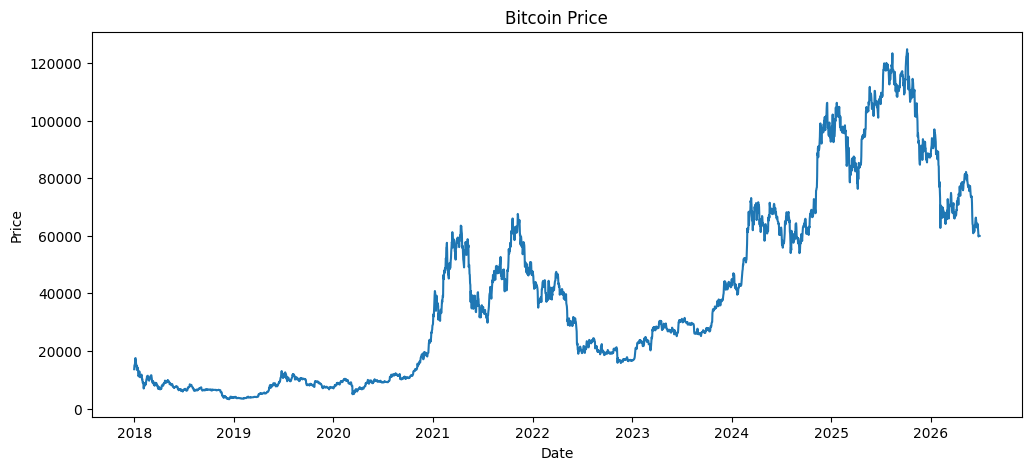

In [3]:
plt.figure(figsize=(12,5))
plt.plot(btc.index, btc["Close"], label="Close Price")
plt.title("Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

Here, we observe that the price movement shows a long-term uptrend, and there are also many ups and downs throughout the period, meaning that the price of bitcoin is very volatile. This is the goal of this project: to forecast the volatility of bitcoin.

(More detail on why we are interested in the volatility will be explained in the later part in this notebook)

**II. Model decision**

In theory, AR/MA and GARCH models must work on stationary data (i.e. a model which is independent with time). We can measure the stationarity of a data using an Augmented Dickey-Fuller test (*adfuller* if in Python) and measure the p-value. If the p-value is larger than 5%, we conclude that the data is non-stationary (i.e. accept the null hypothesis which states that the data is non-stationary).

In [7]:
print(f"p-value = {adfuller(np.log(btc["Close"]))[1]}") #The 2nd index (starting from 0) of the adfuller summary shows the p-value

p-value = 0.7992215799066457


It is visible that the p-value of the log data is significantly higher than 5%, meaning that the price data is non-stationary (we can also confirm it visually since the price data shows an uptrend). To make the data stationary, we transform the data by differencing it. Differencing returns a plot representing the signed difference of the current data and the previous data (e.g., if we have y = f(x), then the differencing result will be y* = f(x) - f(x-1)). We will keep differencing it until the resulting data is stationary.

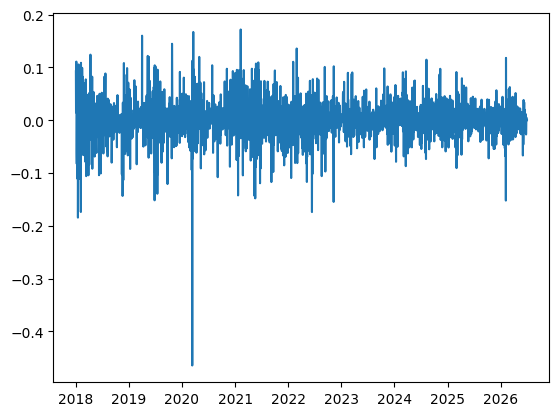

p-value = 0.0 (The data is stationary)


In [37]:
log_diff = np.log(btc["Close"]).diff().dropna()
plt.plot(log_diff)
plt.show()
print(f"p-value = {adfuller(log_diff)[1]} (The data is stationary)")

Perfect. Since the p-value is less than 5%, we now have successfully transformed the non-stationary log price data to a stationary differenced data. This is called first-order differencing, since we only different it once. This is the data we will use to feed into the model.

First, we will try ARMA (Auto-Regressive and Moving Average), one of the most widely used time-series forecasting model. ARMA has 2 parameters: p and q, where we can approximate those value by looking at ACF (Auto-Correlation Function) and PACF (Partial Auto-Correlation Function) plot. p corresponds to PACF plot while q corresponds to ACF plot. The data point at x = i in PACF denotes the correlation between current data point (time = t) and data point with time $t-i$ without taking account of the effect from the time between $t-i$ and $t$. ACF is similar to PACF, with the only difference is that it takes account of the effect from the time between $t-i$ and $t$. I will explain how to determine the p and q value in the next process.


Brief theory:

ARMA consists of two components: Autoregressive model (AR) and Moving average model (MA). Autoregressive model tells us how the current data point correlates with previous data points, while moving average model tells us how the current data point correlates with previous error terms (i.e. shock terms). The equation for both can be written as follows:

AR(p): $X_t = c + \sum_{i = 1}^{p}\phi_iX_{t-i} + \epsilon_t$
where c is a constant term, $X_t$ is a data point at time t,  $\phi_i$ is the regression coefficient, and $\epsilon_t$ is the error term at time t.

MA(q): $X_t = c + \sum_{i = 1}^{q}\theta_i\epsilon_{t-i} + \epsilon_t$ where c is a constant term, $X_t$ is a data point at time t,  $\theta_i$ is the regression coefficient, and $\epsilon_t$ is the error term at time t.

ARMA is the combination of both models, whose equation can be represented as follows:

$X_t = c + \sum_{i = 1}^{p}\phi_iX_{t-i} + \sum_{i = 1}^{q}\theta_i\epsilon_{t-i} + \epsilon_t$

Therefore, we can see that p and q are the significances of the AR and MA model, respectively.

Above: ACF, Below: PACF


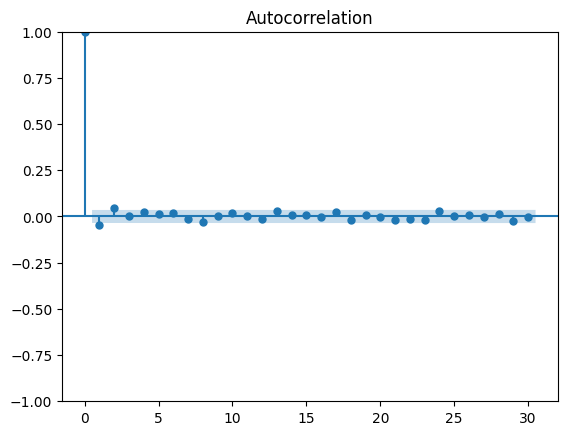

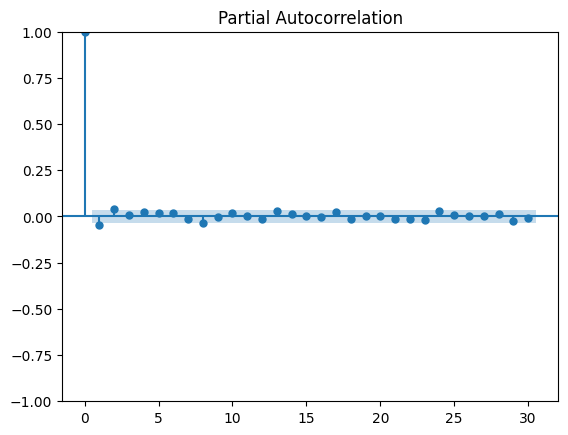

In [20]:
print("Above: ACF, Below: PACF")
plot_acf(log_diff, lags = 30)
plot_pacf(log_diff, lags = 30)
plt.show()

Note that at x = 0, the autocorrelation value is 1, since the correlation of current data point and itself is always 1. We notice from the plots that the data points shows pure noises from x = 1 onwards, meaning that the value of p and q must not be large (if large then the data points before x = p or x = q is high in magnitude). Therefore, we try some small values of p and q.

In [ ]:
models = [(0,0,0), (1,0,0), (0,0,1), (1,0,1)] #parameters in (p,d,q), where d is the differencing order. Since log_diff is already stationary, we do not have to difference it anymore, so we set d = 0.
for order in models:
    model = ARIMA(log_diff, order=order).fit()
    print(order, model.aic)

'''
Output:
(0, 0, 0) -12194.653191743266
(1, 0, 0) -12199.6095918539
(0, 0, 1) -12199.038298122685
(1, 0, 1) -12201.278151333841
'''

Above are the AIC values. We prefer the model parameters which leads to lowest AIC value. Therefore, (p,d,q) = (1,0,1) is our choice. Let's evaluate the result.

In [28]:
model = ARIMA(log_diff, order=(1,0,1)).fit()
print(model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                BTC-USD   No. Observations:                 3100
Model:                 ARIMA(1, 0, 1)   Log Likelihood                6104.639
Date:                Mon, 29 Jun 2026   AIC                         -12201.278
Time:                        05:35:05   BIC                         -12177.122
Sample:                             0   HQIC                        -12192.604
                               - 3100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.778      0.437      -0.001       0.002
ar.L1         -0.4515      0.207     -2.180      0.029      -0.857      -0.046
ma.L1          0.3995      0.212      1.888      0.0

From the above result, we see a very high Jarque-Bera (JB) statistics, with a zero p-value. This represents that the data is not normally distributed. Moreover, a high value of Kurtosis tells us that our stationary data is heavy-tailed, strongly suggesting that normality assumption is not compatible.

We also see that the p-value of the H-test is 0, meaning that heteroskedasticity (volatility clustering/inconsistent variance) is present. Therefore, we can conclude that ARMA alone fails to capture the volatility dynamics.

To successfully capture the volatility dynamics, we must augment GARCH model as supplementary to our ARMA model.

In [30]:
model_garch = arch_model(log_diff * 10, mean='ARX', lags=1, vol='Garch', p=1, q=1, dist = 't') #The multiplication of 10 is due to the recommended scaling
res = model_garch.fit(disp = 'off')
print(res.summary())

                              AR - GARCH Model Results                              
Dep. Variable:                      BTC-USD   R-squared:                       0.002
Mean Model:                              AR   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:               -442.768
Distribution:      Standardized Student's t   AIC:                           897.536
Method:                  Maximum Likelihood   BIC:                           933.769
                                              No. Observations:                 3099
Date:                      Mon, Jun 29 2026   Df Residuals:                     3097
Time:                              06:00:24   Df Model:                            2
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
-----------------------------------------------------------------------------

We change the distribution to studentized-t to handle the heavy tail in our stationary data.

Here, we see that the value of R-squared is near-zero, which implies that our ARMA-GARCH model has low ability to capture the price movement, leading to low contribution effect of ARMA, meaning that GARCH dominates the model.

Since we are not able to combine ARMA and GARCH model within the same environment to construct ARMA(1,1) + GARCH(1,1) model, the most we can do is to implement AR(1) + GARCH(1,1) as shown in the above code (note: lags = 1 is used as the parameter of AR).

We also see that alpha + beta = 0.0748 + 0.9252 = 1 (as of June 29th, 2026), meaning that the volatility persistence is high, making easy for us to forecast volatility. In addition, GARCH is highly compatible for forecast volatility, which stronger motivates us to aim for volatility prediction.

Next, we will perform two diagnostic checks of the model:

1. Ljung-Box test: To test whether there exist autocorrelations of the residuals. If p-value < 0.05, then autocorrelation is present. We aim to achieve p-value > 0.05.

2. ARCH-test: To test whether uncaptured heteroskedasticity exists. If p-value < 0.05, then there exists uncaptured heteroskedasticity. We aim to achieve p-value > 0.05.

In [ ]:
acorr_ljungbox(res.std_resid.dropna(), lags=[10], return_df=True)
het_arch(res.std_resid.dropna())

'''
(np.float64(5.881654323369617),
 np.float64(0.8251061544029646), --> p-value of Ljung-Box test
 0.5871890072827674,
 0.8257426398691343) --> p-value of ARCH-test
'''

Since both p-values for Ljung-Box test and ARCH-test are significantly greater than 0.05, we can conclude that the model is adequate. Thus, the decided model is AR(1) + GARCH(1,1).

**III. Train-test split**

Train-test split is a machine learning training approach which utilizes the majority part of data as the training material, and leaves the rest of the part of data for the model to forecast. Here, we will use 80% of the data for training, and 20% of the data for testing.

In [39]:
#Initialization
train_size = int(len(btc) * 0.8)
train = log_diff[:train_size]
test = log_diff[train_size:]
print(len(train), len(test))

2480 620


Our goal is to forecast the variance of Bitcoin price and evaluate by comparing forecasted variance and actual variance. However, we cannot measure the real variance of a single time point. Therefore, we must find an appropriate estimator for the true variance in a single time point.

Limitations due to unavailability of intraday price data leads to limited estimator options. One of unbiased estimators suitable for low-frequency data is squared return, which depends on the previous data point. Therefore, we try to compare the forecasted variance and the squared return.

Nevertheless, squared return may exhibit large noise, meaning that pointwise comparisons with model-implied variance may appear poor even when the model is correctly specified.

In [ ]:
forecasts = []
actuals = []

history = train * 10 #Scaling to x10

for t in range(len(test)):
    model = arch_model(history, vol='GARCH', lags = 1, p=1, q=1, dist='t')
    res = model.fit(disp='off')

    fcast = res.forecast(horizon=1)
    var_forecast = fcast.variance.iloc[0, 0] #Forecasted variance
    forecasts.append(var_forecast)
    actuals.append((test.iloc[t]*10)**2)  #Squared-return

    history = pd.concat([history, test.iloc[t:t+1] * 10])

To evaluate the adequacy of the forecast, we will use QLIKE (Quasi-Likelihood) metric, which is derived from the Gaussian Likelihood. We use QLIKE due to its scale independency and robustness to high noises. Lower value of QLIKE implies better forecast.

Why MSE (Mean Squared Error) or MAE (Mean Absolute Error) is not used? As visible on the plotted data, the magnitude of returns is low for the majority of the period, which leads to low value of both MAE and MSE. Moreover, both MSE and MAE are scale-dependent. Since differenced log price tends to be small, low MAE or MSE cannot explain the adequacy of the forecasting model.

In [47]:
forecasts = np.array(forecasts)
actuals = np.array(actuals)

qlike = np.mean(np.log(forecasts) + actuals / forecasts)

print(f"QLIKE: {qlike}")

QLIKE: -1.7780773547413513


The QLIKE value of -1.77 is consistent with the scale of the data and arises naturally due to the small magnitude of financial return variances. As QLIKE is derived from a likelihood framework, its value reflects the average quasi-log-likelihood of the model rather than an absolute performance metric. In the absence of alternative model specifications, the result is interpreted as internally consistent, indicating that the model provides a coherent probabilistic description of the observed returns. However, since QLIKE is inherently a relative measure, definitive conclusions regarding model goodness require comparison with benchmark models.

Below is the visualization of the comparison of forecasted variance and the squared return.

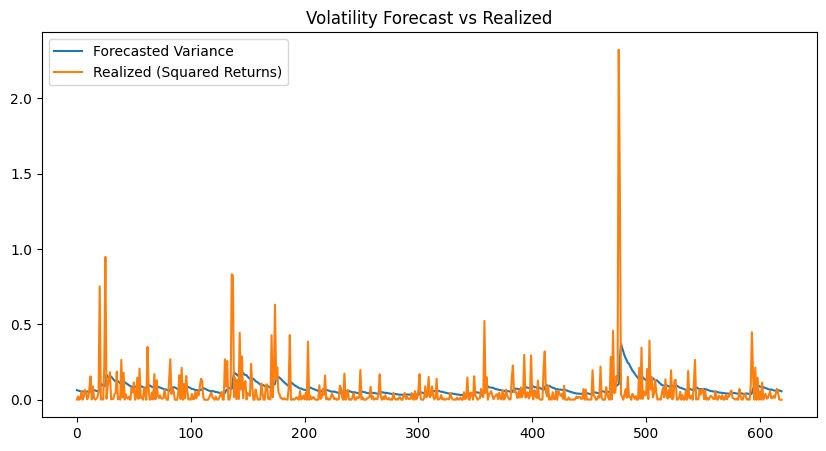

In [46]:
plt.figure(figsize=(10,5))
plt.plot(forecasts, label='Forecasted Variance')
plt.plot(actuals, label='Realized (Squared Returns)')
plt.legend()
plt.title("Volatility Forecast vs Realized")
plt.show()